**Dataset Description:**

This dataset contains scraped data from **Cars24**, a popular online marketplace for buying and selling used cars. It provides detailed information on various **pre-owned car listings**, including:

* Model Name and Manufacturing Year
* Price and KM Driven (mileage)
* Engine Capacity and Fuel Type
* Transmission Type (Manual/Automatic)
* Ownership History (First-hand, Second-hand, etc.)
* Availability of Spare Key
* Imperfections and Repainted Parts

In [62]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/used-car-price-data-from-cars24/cars24data.csv


In [63]:
cars_df = pd.read_csv('/kaggle/input/used-car-price-data-from-cars24/cars24data.csv')
cars_df.head()

,Model Name,Price,Manufacturing_year,Engine capacity,Spare key,Transmission,KM driven,Ownership,Fuel type,Imperfections,Repainted Parts
0,2017 Maruti Swift VXI,561000,2017,1197,No,Manual,25847,2,Petrol,6,2
1,2016 Maruti Baleno DELTA PETROL 1.2,498000,2016,1197,Yes,Manual,55511,2,Petrol,12,1
2,2020 Maruti Swift VXI,577000,2020,1197,No,Manual,47110,1,Petrol,4,2
3,2022 Maruti Ertiga VXI AT SHVS,1084000,2022,1462,Yes,Automatic,35378,1,Petrol,2,3
4,2019 Maruti Dzire VXI,603000,2019,1197,Yes,Manual,91856,1,Petrol,3,2


cars_df.info()

In [64]:
cars_df = cars_df.drop(['Model Name'], axis=1)
for cat_column in cars_df.select_dtypes(object):
    print(cars_df[cat_column].unique())


['No' 'Yes']
['Manual' 'Automatic']
['Petrol' 'Diesel' 'CNG']


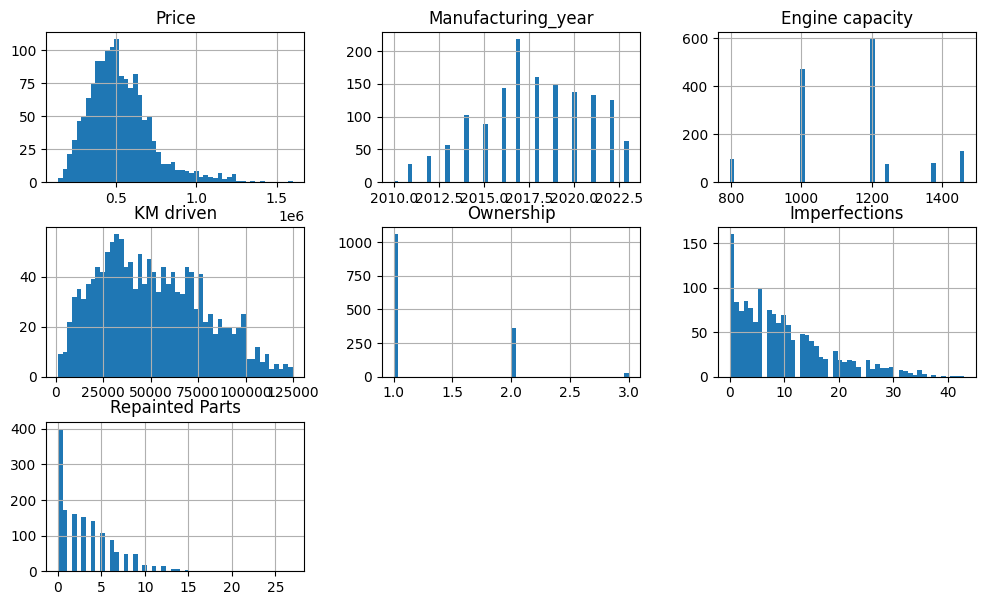

In [65]:
import matplotlib.pyplot as plt

cars_df.hist(bins=50, figsize=(12, 7))
plt.show()

In [66]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(cars_df, test_size=0.2, random_state=42)

In [67]:
cars_df["engine_cat"] = pd.cut(cars_df["Engine capacity"],
                                bins=[0., 800, 1000, 1200, 1400, np.inf],
                                labels=[1, 2, 3, 4, 5])

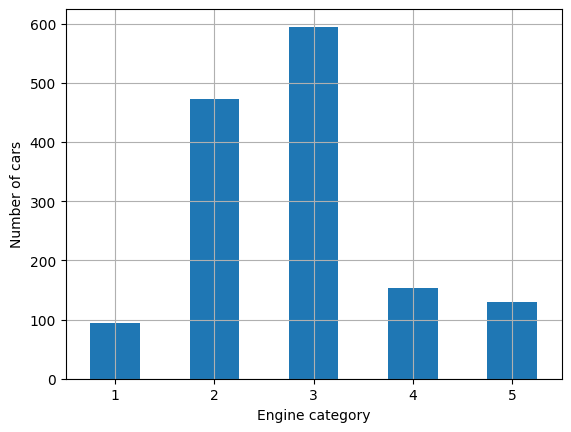

In [68]:
cars_df["engine_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Engine category")
plt.ylabel("Number of cars")
plt.show()

In [69]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(cars_df, cars_df["engine_cat"]):
    strat_train_set_n = cars_df.iloc[train_index]
    strat_test_set_n = cars_df.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])    

In [70]:
strat_train_set, strat_test_set = train_test_split(cars_df, test_size=0.2,
                                                  stratify=cars_df["engine_cat"],
                                                  random_state=42)

In [71]:
strat_test_set["engine_cat"].value_counts() / len(strat_test_set)

engine_cat
3    0.411765
2    0.325260
4    0.107266
5    0.089965
1    0.065744
Name: count, dtype: float64

In [72]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("engine_cat", axis=1, inplace=True)

In [73]:
cars_df = strat_train_set.copy()

In [74]:
corr_matrix = cars_df.corr(numeric_only=True)

In [75]:
corr_matrix["Price"].sort_values(ascending=False)

Price                 1.000000
Engine capacity       0.716924
Manufacturing_year    0.621273
Ownership            -0.184968
Repainted Parts      -0.215439
Imperfections        -0.249723
KM driven            -0.306108
Name: Price, dtype: float64

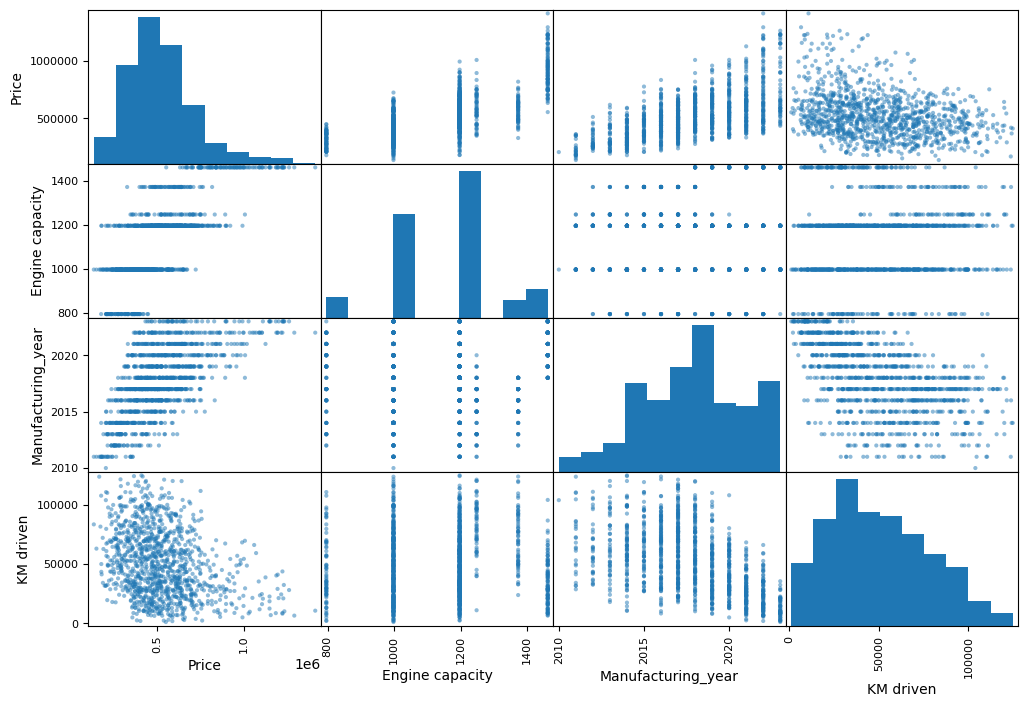

In [76]:
from pandas.plotting import scatter_matrix

attributes = ["Price", "Engine capacity", "Manufacturing_year", "KM driven"]
scatter_matrix(cars_df[attributes], figsize=(12, 8))
plt.show()

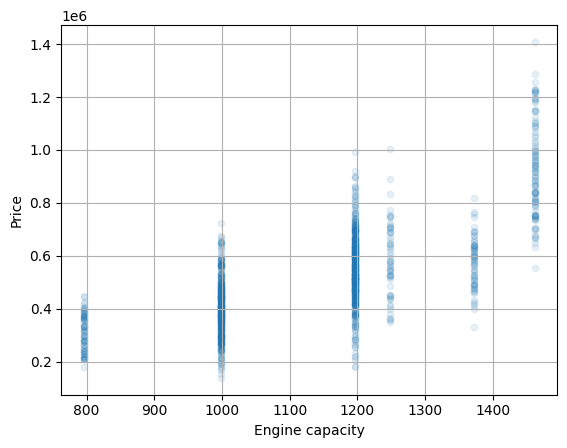

In [77]:
cars_df.plot(kind="scatter", x="Engine capacity", y="Price",
            alpha=0.1, grid=True)
plt.show()

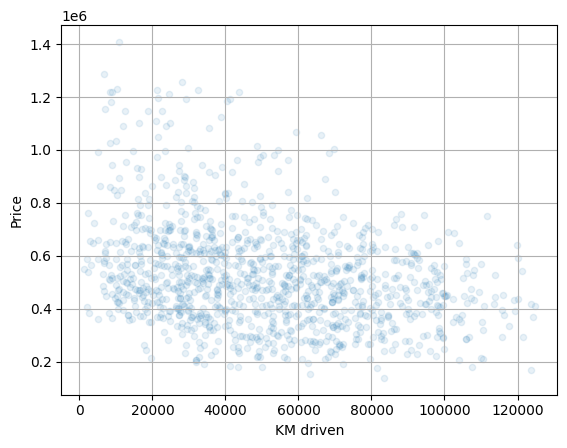

In [78]:
cars_df.plot(kind="scatter", x="KM driven", y="Price",
            alpha=0.1, grid=True)
plt.show()

In [79]:
cars_df = strat_train_set.drop("Price", axis=1)
cars_labels = strat_train_set["Price"].copy()

In [80]:
cars_num = cars_df.select_dtypes(include=[np.number])

In [81]:
cars_num.head()

,Manufacturing_year,Engine capacity,KM driven,Ownership,Imperfections,Repainted Parts
1325,2021,1197,27957,1,11,2
895,2019,1197,22779,2,2,3
265,2015,796,68920,2,11,6
218,2012,1248,62234,2,4,12
1189,2016,998,19613,2,12,7


In [82]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
imputer.fit(cars_num)
X = imputer.transform(cars_num)

In [83]:
cars_tr = pd.DataFrame(X,
                      columns=cars_num.columns,
                      index=cars_num.index)
cars_tr.head()

,Manufacturing_year,Engine capacity,KM driven,Ownership,Imperfections,Repainted Parts
1325,2021.0,1197.0,27957.0,1.0,11.0,2.0
895,2019.0,1197.0,22779.0,2.0,2.0,3.0
265,2015.0,796.0,68920.0,2.0,11.0,6.0
218,2012.0,1248.0,62234.0,2.0,4.0,12.0
1189,2016.0,998.0,19613.0,2.0,12.0,7.0


In [84]:
cars_cat = cars_df.select_dtypes(include=[object])
cars_cat.head()

,Spare key,Transmission,Fuel type
1325,Yes,Manual,Petrol
895,Yes,Automatic,Petrol
265,Yes,Manual,CNG
218,No,Manual,Diesel
1189,No,Manual,Petrol


In [85]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
cars_cat_encoded = ordinal_encoder.fit_transform(cars_cat)

In [86]:
cars_cat_encoded[:8]

array([[1., 1., 2.],
       [1., 0., 2.],
       [1., 1., 0.],
       [0., 1., 1.],
       [0., 1., 2.],
       [1., 1., 2.],
       [1., 0., 2.],
       [0., 0., 2.]])

In [87]:
ordinal_encoder.categories_

[array(['No', 'Yes'], dtype=object),
 array(['Automatic', 'Manual'], dtype=object),
 array(['CNG', 'Diesel', 'Petrol'], dtype=object)]

In [88]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
cars_cat_1hot = cat_encoder.fit_transform(cars_cat)

In [89]:
cars_cat_1hot.toarray()

array([[0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 1., ..., 0., 0., 1.],
       [0., 1., 0., ..., 1., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 1.],
       [0., 1., 1., ..., 0., 0., 1.]])

In [90]:
cat_encoder.categories_

[array(['No', 'Yes'], dtype=object),
 array(['Automatic', 'Manual'], dtype=object),
 array(['CNG', 'Diesel', 'Petrol'], dtype=object)]

In [91]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
cars_num_std_scaled = std_scaler.fit_transform(cars_num)

In [92]:
cars_num_std_scaled[:5]

array([[ 1.0563374 ,  0.32418939, -0.81585729, -0.58476922,  0.17070352,
        -0.36302546],
       [ 0.39376223,  0.32418939, -1.00150629,  1.48248833, -0.9037063 ,
        -0.06454934],
       [-0.9313881 , -2.04825212,  0.6528063 ,  1.48248833,  0.17070352,
         0.83087904],
       [-1.92525085,  0.62592135,  0.41309034,  1.48248833, -0.66494857,
         2.6217358 ],
       [-0.60010052, -0.8531569 , -1.11501822,  1.48248833,  0.29008239,
         1.12935517]])

In [93]:
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

In [94]:
from sklearn import set_config

set_config(display='diagram')

In [95]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

In [96]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

In [97]:
cars_prepared = preprocessing.fit_transform(cars_df)

In [98]:
cars_prepared_fr = pd.DataFrame(
    cars_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=cars_df.index
)
cars_prepared_fr.head()

,pipeline-1__Manufacturing_year,pipeline-1__Engine capacity,pipeline-1__KM driven,pipeline-1__Ownership,pipeline-1__Imperfections,pipeline-1__Repainted Parts,pipeline-2__Spare key_No,pipeline-2__Spare key_Yes,pipeline-2__Transmission_Automatic,pipeline-2__Transmission_Manual,pipeline-2__Fuel type_CNG,pipeline-2__Fuel type_Diesel,pipeline-2__Fuel type_Petrol
1325,1.056337,0.324189,-0.815857,-0.584769,0.170704,-0.363025,0.0,1.0,0.0,1.0,0.0,0.0,1.0
895,0.393762,0.324189,-1.001506,1.482488,-0.903706,-0.064549,0.0,1.0,1.0,0.0,0.0,0.0,1.0
265,-0.931388,-2.048252,0.652806,1.482488,0.170704,0.830879,0.0,1.0,0.0,1.0,1.0,0.0,0.0
218,-1.925251,0.625921,0.413090,1.482488,-0.664949,2.621736,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1189,-0.600101,-0.853157,-1.115018,1.482488,0.290082,1.129355,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [99]:
# cars_df["Imperfections"] = cars_df["Imperfections"].replace(0, 1e-10)
# cars_df["Repainted Parts"] = cars_df["Repainted Parts"].replace(0, 1e-10)

In [100]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

preprocessing = ColumnTransformer(
    [
        # ("log", log_pipeline, ["Imperfections", "Repainted Parts"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline
)

In [101]:
cars_prepared = preprocessing.fit_transform(cars_df)
cars_prepared.shape

(1156, 13)

In [102]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(cars_df, cars_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7de33b9f3d30>)])),
                ('linearregression', LinearRegression())])

In [103]:
cars_predictions = lin_reg.predict(cars_df)
cars_predictions[:5].round(-2)

array([657900., 637400., 170000., 467500., 340000.])

In [104]:
cars_labels.iloc[:5].values

array([730000, 648000, 237000, 356000, 352000])

In [105]:
error_ratios = cars_predictions[:5].round(-2) / cars_labels[:5].values - 1
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

-9.9%, -1.6%, -28.3%, 31.3%, -3.4%


In [106]:
try:
  from sklearn.metrics import root_mean_squared_error
except ImportError:
  from sklearn.metrics import mean_squared_error

  def root_mean_squared_error(labels, predictions):
    return mean_squared_error(labels, predictions, squared=False)

lin_rmse = root_mean_squared_error(cars_labels, cars_predictions)
lin_rmse

81982.99063623442

In [107]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(cars_df, cars_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7de33b9f3d30>)])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [108]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, cars_df, cars_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

In [109]:
pd.Series(tree_rmses).describe()

count        10.000000
mean     102324.441451
std       10114.679406
min       88036.010419
25%       97435.910166
50%       98898.743907
75%      110865.741329
max      118843.384334
dtype: float64

In [110]:
lin_rmses = -cross_val_score(lin_reg, cars_df, cars_labels,
                             scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()

count       10.000000
mean     82650.071628
std       6387.077805
min      73544.644172
25%      76550.506486
50%      83981.339125
75%      87723.786176
max      90175.845733
dtype: float64

In [111]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, cars_df, cars_labels,
                                scoring="neg_root_mean_squared_error", cv=10)

In [112]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     72971.725297
std       4466.077237
min      67005.799081
25%      70787.104012
50%      72664.285858
75%      75430.055745
max      81899.185851
dtype: float64

In [113]:
forest_reg.fit(cars_df, cars_labels)
cars_predictions = forest_reg.predict(cars_df)
forest_rmse = root_mean_squared_error(cars_labels, cars_predictions)
forest_rmse

26826.187092602922

In [114]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

In [115]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])

params_distribs = {
    'random_forest__max_features': randint(low=2, high=20)
}

rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=params_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42
)

rnd_search.fit(cars_df, cars_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('cat',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehotencoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               <sklearn.compose._column_transformer.make_column_selector object at 0x7de33b9f3d30>)])),
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7de33b703970>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [116]:
# display the results
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by='mean_test_score', ascending=False, inplace=True)
cv_res = cv_res[[
    "param_random_forest__max_features",
    "split0_test_score",
    "split1_test_score",
    "split2_test_score",
    "mean_test_score"
]]
score_cols = ["split0", "split1", "spli2", "mean_test_rmse"]
cv_res.columns = ["max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)
cv_res.head()

,max_features,split0,split1,spli2,mean_test_rmse
0,8,75422,72660,73231,73771
4,8,75422,72660,73231,73771
7,5,75069,73496,73199,73921
3,9,76483,73661,73311,74485
8,9,76483,73661,73311,74485


In [117]:
final_model = rnd_search.best_estimator_ # includes preprocessing
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.  , 0.  , 0.01, 0.01, 0.  , 0.01, 0.  , 0.26, 0.55, 0.07, 0.01,
       0.05, 0.03])

In [118]:
sorted(zip(feature_importances,
           final_model["preprocessing"].get_feature_names_out()),
       reverse=True)

[(0.552901104131062, 'remainder__Engine capacity'),
 (0.25810999055717865, 'remainder__Manufacturing_year'),
 (0.06702784254651324, 'remainder__KM driven'),
 (0.04560175291633546, 'remainder__Imperfections'),
 (0.027824020742892024, 'remainder__Repainted Parts'),
 (0.011737793794873795, 'cat__Transmission_Automatic'),
 (0.009300889270781633, 'cat__Transmission_Manual'),
 (0.006290518506544074, 'remainder__Ownership'),
 (0.005790115130485194, 'cat__Fuel type_Diesel'),
 (0.004988116647182438, 'cat__Fuel type_Petrol'),
 (0.004364998423748842, 'cat__Spare key_No'),
 (0.003943521675086398, 'cat__Spare key_Yes'),
 (0.002119335657316151, 'cat__Fuel type_CNG')]

In [119]:
X_test = strat_test_set.drop("Price", axis=1)
y_test = strat_test_set["Price"].copy()

# X_test["Imperfections"] = cars_df["Imperfections"].replace(0, 1e-10)
# X_test["Repainted Parts"] = cars_df["Repainted Parts"].replace(0, 1e-10)

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

82051.20428047009


In [120]:
from scipy import stats

def rmse(squared_error):
  return np.sqrt(np.mean(squared_error))

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = stats.bootstrap([squared_errors], rmse,
                              confidence_level=confidence, random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval

In [121]:
rmse_lower, rmse_upper

(67684.1140968391, 120897.47058218204)

In [122]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, final_predictions)
r2

0.8256229336378171